<a href="https://colab.research.google.com/github/Siddhi-S-Thakur/Deep-Learning/blob/main/L5_tf_2401122.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [14]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [15]:
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("Number of classes:", len(np.unique(y_train)))

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)
Number of classes: 10


In [16]:
X_train[:5]

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
   

In [17]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

###### Here dependent variable i.e (X_train, X_test) is image features which is stored as a matrix and independent/ target variable i.e (y_train, y_test) is the image lable which is represented as a matrix in dependebt variables eg 7,4 etc

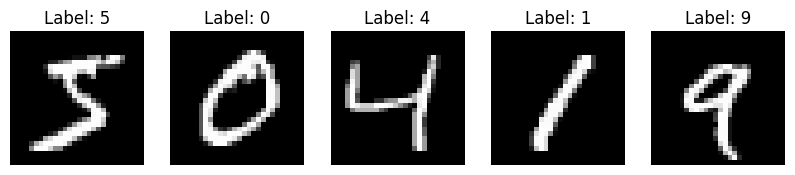

In [18]:
plt.figure(figsize = (10,4))

for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(X_train[i], cmap = 'gray')
  plt.title("Label: " + str(y_train[i]))
  plt.axis("off")

plt.show()

In [19]:
X_train = X_train / 255.0
X_test = X_test /255.0

In [20]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("New training data shape:", X_train.shape)

New training data shape: (60000, 28, 28, 1)


##### The original MNIST training data has the shape (60000, 28, 28), where 60000 represents the number of images and each image is a 28 × 28 pixel matrix. However, Convolutional Neural Networks require input data in the format (samples, height, width, channels).Since MNIST images are grayscale, they have only one color channel. Therefore, we reshape the data to (60000, 28, 28, 1) by adding a channel dimension.The command reshape(-1, 28, 28, 1) performs this transformation:-1 automatically determines the number of images.28, 28 represent the image height and width.1 represents the grayscale channel.This reshaping ensures the data is compatible with CNN layers such as Conv2D, which expect a channel dimension for applying convolution filters.

In [21]:
model = Sequential()

# 1st Convolution layer
model.add(Conv2D(32, (3,3), activation = 'relu', input_shape = (28,28,1)))

# 1st Maxpooling layer
model.add(MaxPooling2D(pool_size = (2,2)))

# 2nd convolution layer
model.add(Conv2D(64, (3,3), activation = 'relu'))

# 2nd maxpooling layer
model.add(MaxPooling2D(pool_size = (2,2)))

#Flatten layer
model.add(Flatten())

model.add(Dense(64, activation='relu'))

# Output layer
model.add(Dense(10, activation='softmax'))

###### The model is created using a Sequential structure, where layers are added one after another. The first Conv2D layer uses 32 filters of size 3×3 with ReLU activation to extract basic features like edges from the 28×28 grayscale images. A MaxPooling2D layer (2×2) then reduces the size of the feature maps and keeps the most important information.Next, a second Conv2D layer with 64 filters detects more complex patterns in the image, followed by another MaxPooling2D layer to further reduce the feature map size.The Flatten layer converts the 2D feature maps into a 1D vector so it can be used by dense (fully connected) layers. A Dense layer with 64 neurons and ReLU activation helps the network learn combinations of the extracted features.Finally, the output Dense layer with 10 neurons and Softmax activation predicts the probability of the image belonging to one of the 10 digit classes (0–9).

In [22]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 48s 27ms/step - accuracy: 0.9489 - loss: 0.1646 - val_accuracy: 0.9817 - val_loss: 0.0612
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 44s 26ms/step - accuracy: 0.9838 - loss: 0.0525 - val_accuracy: 0.9888 - val_loss: 0.0406
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 45s 27ms/step - accuracy: 0.9881 - loss: 0.0376 - val_accuracy: 0.9880 - val_loss: 0.0467
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - accuracy: 0.9915 - loss: 0.0273 - val_accuracy: 0.9903 - val_loss: 0.0381
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 84s 27ms/step - accuracy: 0.9939 - loss: 0.0200 - val_accuracy: 0.9863 - val_loss: 0.0447


In [25]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9891 - loss: 0.0358
Test Accuracy: 0.9890999794006348
